## Email Spam Detection Model

# Setup and Datset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display plots inside notebook
%matplotlib inline

# plot style
plt.style.use("ggplot")
df=pd.read_csv("../dataset/spam.csv",encoding='latin-1')



# Exploratory Data Anaylsis

First 5 Rows


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


last 5 Rows


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


Dataset shape
(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
Label      0
Message    0
dtype: int64
Duplicate Rows: 403
duplicates removed
(5169, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5169 non-null   object
 1   Message  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB
Label
ham     4516
spam     653
Name: count, dtype: int64


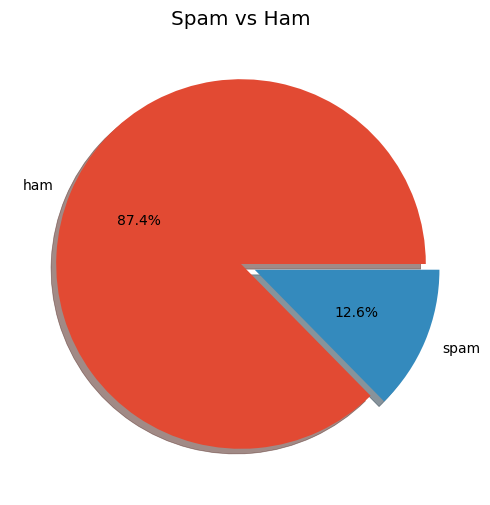

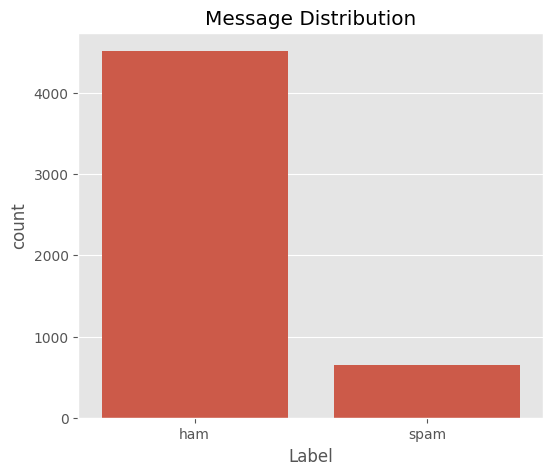

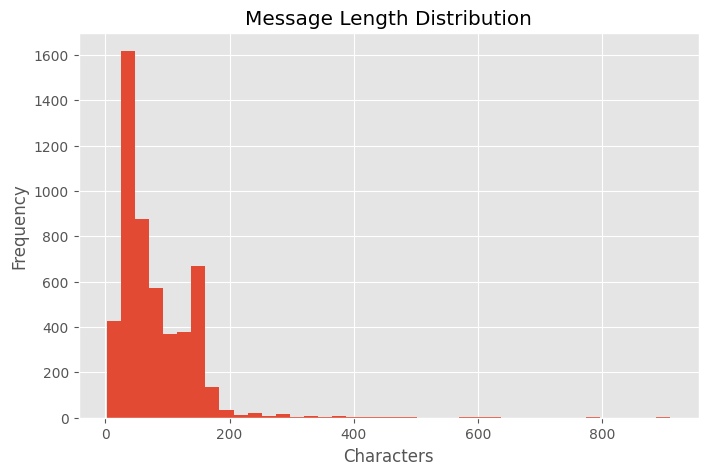

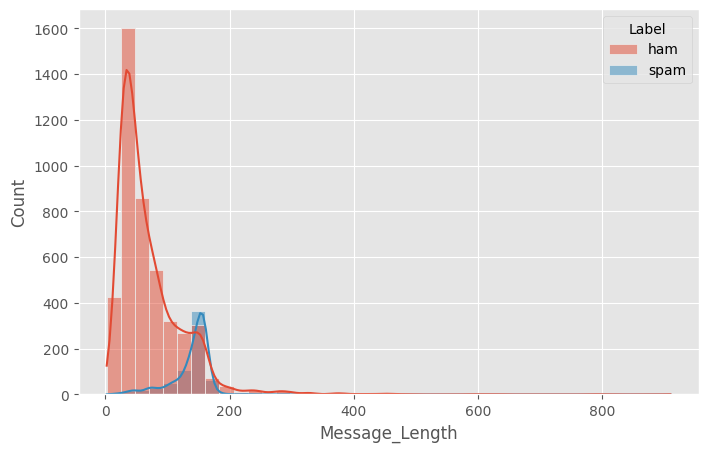

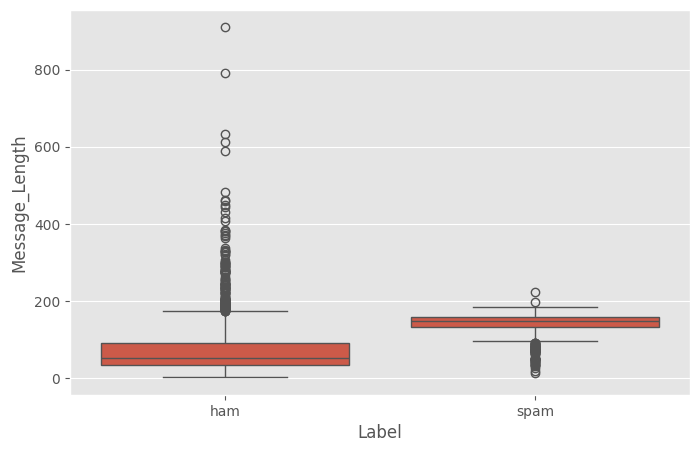

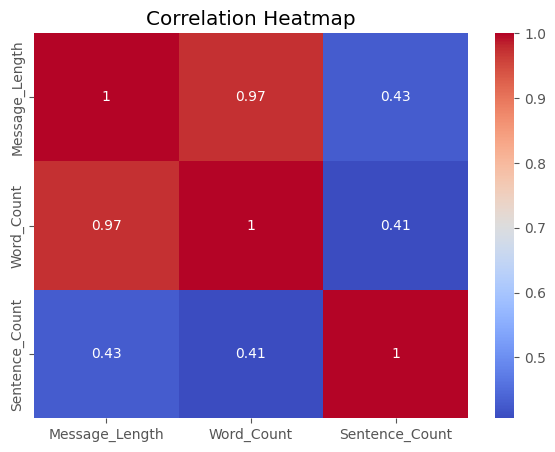

Total Messages : 5169
Spam Messages : 653
Ham Messages : 4516
Average Message Length : 78.97794544399304
Average Word Count : 15.34068485200232
Clean Dataset Saved Successfully


In [8]:
print("First 5 Rows")
display(df.head())

print("last 5 Rows")    
display(df.tail())

print("Dataset shape")
print(df.shape)

print(df.columns)
df.info()
df.describe(include='all')

# rename columns for better understanding
df.rename(columns={
    "v1":"Label","v2":"Message"
},
          inplace=True)
df.head()

# Remove empty columns
df.drop(
    columns=[
        "Unnamed: 2",
        "Unnamed: 3",
        "Unnamed: 4"
    ],
    inplace=True
)

df.head()

# check missing values
print(df.isnull().sum())

#check duplicates
print("Duplicate Rows:", df.duplicated().sum())

#remove duplicates
df.drop_duplicates(inplace=True)
print("duplicates removed")
print(df.shape)
df.info()
#label distribution
print(df["Label"].value_counts())

#pie chart
plt.figure(figsize=(6,6))

df["Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    explode=(0,0.08),
    shadow=True
)

plt.title("Spam vs Ham")

plt.ylabel("")

plt.show()
#Count Plot
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Label"
)

plt.title("Message Distribution")

plt.show()

#message length
df["Message_Length"] = df["Message"].apply(len)

#word count
df["Word_Count"] = df["Message"].apply(
    lambda x: len(x.split())
)
#sentence count
df["Sentence_Count"] = df["Message"].apply(
    lambda x: len(x.split("."))
)
df.head()
df.describe()
df.groupby("Label").mean(numeric_only=True)
#Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df["Message_Length"],
    bins=40
)

plt.title("Message Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()
#Histogram label

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Message_Length",
    hue="Label",
    bins=40,
    kde=True
)

plt.show()
#Box Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Label",
    y="Message_Length"
)

plt.show()

#Correlation matrix
numeric_df=df.select_dtypes(include="number")
numeric_df.corr()
#Heatmap
plt.figure(figsize=(7,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#longest message
df.sort_values(
    by="Message_Length",
    ascending=False
).head(10)
#spam msg only
spam = df[df["Label"]=="spam"]

spam.head()
#ham msg only
ham = df[df["Label"]=="ham"]

ham.head()


print("Total Messages :",len(df))

print("Spam Messages :",len(df[df["Label"]=="spam"]))

print("Ham Messages :",len(df[df["Label"]=="ham"]))

print("Average Message Length :",df["Message_Length"].mean())

print("Average Word Count :",df["Word_Count"].mean())

df.to_csv(
    "../dataset/cleaned_spam.csv",
    index=False
)

print("Clean Dataset Saved Successfully")